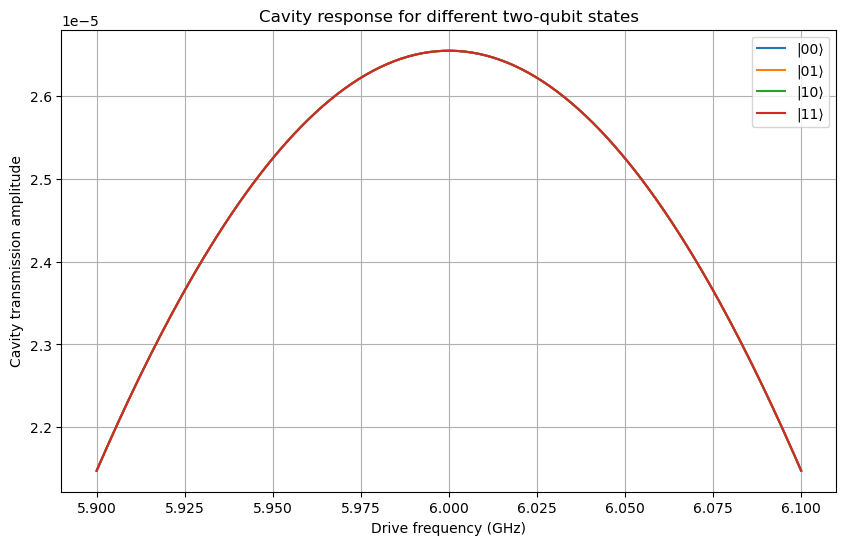

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Constants
ω_r = 6.0 * 2 * np.pi  # Cavity frequency (GHz)
ω_q1 = 5.0 * 2 * np.pi  # Qubit 1 frequency
ω_q2 = 4.8 * 2 * np.pi  # Qubit 2 frequency
g1 = 0.05 * 2 * np.pi  # Coupling of qubit 1 to cavity
g2 = 0.05 * 2 * np.pi  # Coupling of qubit 2 to cavity
Δ1 = ω_q1 - ω_r
Δ2 = ω_q2 - ω_r
χ1 = g1**2 / Δ1
χ2 = g2**2 / Δ2

# Operators
N_cav = 10  # Cavity truncation
a = tensor(destroy(N_cav), qeye(2), qeye(2))
sm1 = tensor(qeye(N_cav), destroy(2), qeye(2))
sm2 = tensor(qeye(N_cav), qeye(2), destroy(2))
sz1 = tensor(qeye(N_cav), sigmaz(), qeye(2))
sz2 = tensor(qeye(N_cav), qeye(2), sigmaz())

# Dispersive Hamiltonian
H0 = ω_r * a.dag() * a + 0.5 * ω_q1 * sz1 + 0.5 * ω_q2 * sz2 + χ1 * a.dag() * a * sz1 + χ2 * a.dag() * a * sz2

# Collapse operators (optional: cavity decay only)
kappa = 0.005 * 2 * np.pi
c_ops = [np.sqrt(kappa) * a]

# Frequencies for probe
freqs = np.linspace(ω_r - 0.1 * 2 * np.pi, ω_r + 0.1 * 2 * np.pi, 200)

# Function to get cavity transmission
def cavity_response(state_qubit):
    # Prepare initial state (cavity vacuum, qubit state)
    psi0 = tensor(basis(N_cav, 0), basis(2, state_qubit[0]), basis(2, state_qubit[1]))
    results = []
    for ω_d in freqs:
        H = H0 + 1e-3 * (a + a.dag()) * np.cos(ω_d)  # drive cavity weakly
        rho_ss = steadystate(H, c_ops)
        response = expect(a, rho_ss)
        results.append(np.abs(response))
    return np.array(results)

# Simulate all four states
states = {
    '|00⟩': (0, 0),
    '|01⟩': (0, 1),
    '|10⟩': (1, 0),
    '|11⟩': (1, 1)
}

# Plot
plt.figure(figsize=(10, 6))
for label, st in states.items():
    resp = cavity_response(st)
    plt.plot(freqs / (2*np.pi), resp, label=label)

plt.xlabel("Drive frequency (GHz)")
plt.ylabel("Cavity transmission amplitude")
plt.title("Cavity response for different two-qubit states")
plt.legend()
plt.grid(True)
plt.show()


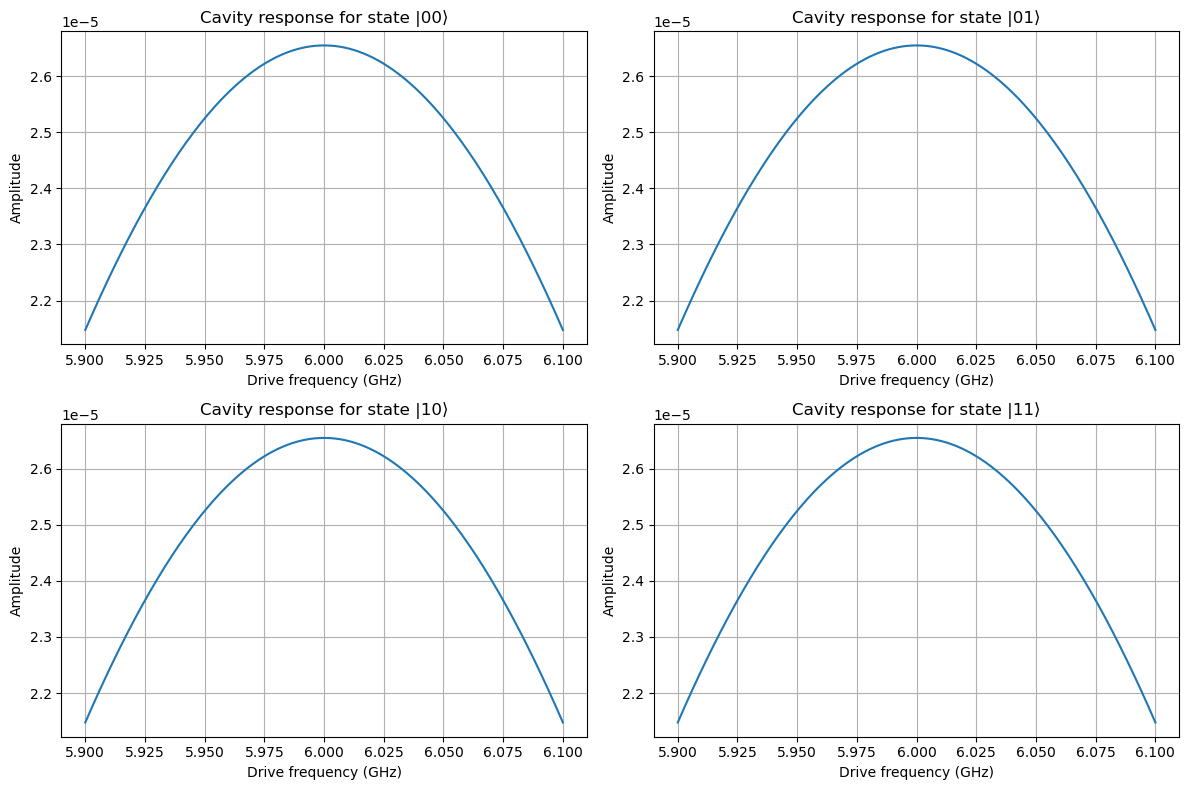

In [2]:

# Parameters
ω_r = 6.0 * 2 * np.pi      # Cavity frequency (GHz)
ω_q1 = 5.0 * 2 * np.pi      # Qubit 1 frequency
ω_q2 = 4.8 * 2 * np.pi      # Qubit 2 frequency
g1 = 0.05 * 2 * np.pi       # Qubit 1-cavity coupling
g2 = 0.05 * 2 * np.pi       # Qubit 2-cavity coupling
Δ1 = ω_q1 - ω_r
Δ2 = ω_q2 - ω_r
χ1 = g1**2 / Δ1             # Dispersive shift 1
χ2 = g2**2 / Δ2             # Dispersive shift 2

# Hilbert space dimensions
N_cav = 10  # cavity truncation
a = tensor(destroy(N_cav), qeye(2), qeye(2))
sm1 = tensor(qeye(N_cav), destroy(2), qeye(2))
sm2 = tensor(qeye(N_cav), qeye(2), destroy(2))
sz1 = tensor(qeye(N_cav), sigmaz(), qeye(2))
sz2 = tensor(qeye(N_cav), qeye(2), sigmaz())

# Dispersive Hamiltonian
H0 = ω_r * a.dag() * a + 0.5 * ω_q1 * sz1 + 0.5 * ω_q2 * sz2 + χ1 * a.dag() * a * sz1 + χ2 * a.dag() * a * sz2

# Collapse operators
kappa = 0.005 * 2 * np.pi
c_ops = [np.sqrt(kappa) * a]

# Drive frequencies
freqs = np.linspace(ω_r - 0.1 * 2 * np.pi, ω_r + 0.1 * 2 * np.pi, 200)

# Function to compute cavity response for a given qubit state
def cavity_response(state_qubit):
    psi0 = tensor(basis(N_cav, 0), basis(2, state_qubit[0]), basis(2, state_qubit[1]))
    results = []
    for ω_d in freqs:
        H = H0 + 1e-3 * (a + a.dag()) * np.cos(ω_d)  # Weak drive
        rho_ss = steadystate(H, c_ops)
        response = expect(a, rho_ss)
        results.append(np.abs(response))
    return np.array(results)

# Define states and labels
states = {
    '|00⟩': (0, 0),
    '|01⟩': (0, 1),
    '|10⟩': (1, 0),
    '|11⟩': (1, 1)
}

# Plot in subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (label, st) in enumerate(states.items()):
    resp = cavity_response(st)
    axs[i].plot(freqs / (2 * np.pi), resp)
    axs[i].set_title(f"Cavity response for state {label}")
    axs[i].set_xlabel("Drive frequency (GHz)")
    axs[i].set_ylabel("Amplitude")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


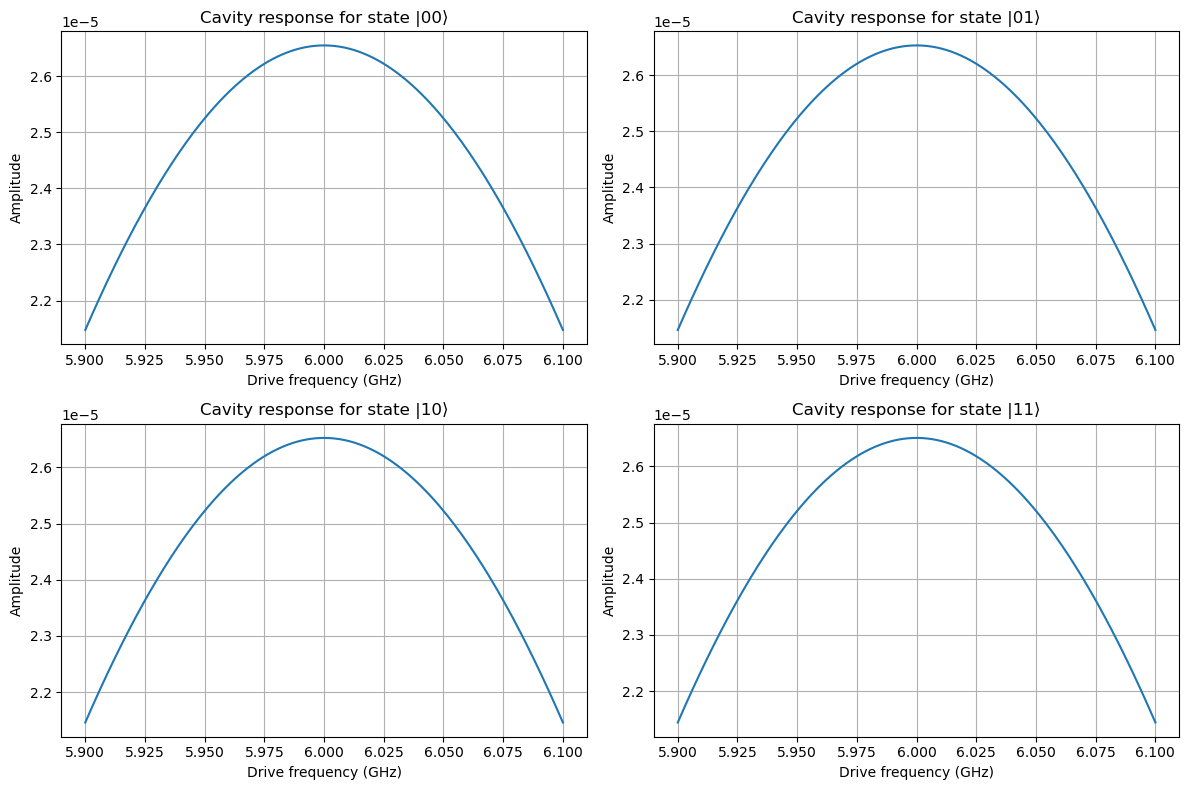

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parameters
ω_r = 6.0 * 2 * np.pi      # Cavity frequency (GHz)
ω_q1 = 5.0 * 2 * np.pi
ω_q2 = 4.8 * 2 * np.pi
g1 = 0.05 * 2 * np.pi
g2 = 0.05 * 2 * np.pi
Δ1 = ω_q1 - ω_r
Δ2 = ω_q2 - ω_r
χ1 = g1**2 / Δ1
χ2 = g2**2 / Δ2

# Hilbert space (cavity only)
N_cav = 10
a = destroy(N_cav)

# Collapse operator for cavity decay
kappa = 0.005 * 2 * np.pi
c_ops = [np.sqrt(kappa) * a]

# Probe frequencies
freqs = np.linspace(ω_r - 0.1 * 2 * np.pi, ω_r + 0.1 * 2 * np.pi, 200)

# Function to compute steady-state response for a given qubit state
def cavity_response(z1, z2):
    ω_eff = ω_r + χ1 * z1 + χ2 * z2
    results = []
    for ω_d in freqs:
        # Drive term in lab frame (weak drive, detuned from ω_eff)
        H = ω_eff * a.dag() * a + 1e-3 * (a + a.dag()) * np.cos(ω_d)
        rho_ss = steadystate(H, c_ops)
        response = expect(a, rho_ss)
        results.append(np.abs(response))
    return np.array(results)

# Define qubit z-values for each basis state
states = {
    "|00⟩": (+1, +1),
    "|01⟩": (+1, -1),
    "|10⟩": (-1, +1),
    "|11⟩": (-1, -1),
}

# Plot
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (label, (z1, z2)) in enumerate(states.items()):
    resp = cavity_response(z1, z2)
    axs[i].plot(freqs / (2 * np.pi), resp)
    axs[i].set_title(f"Cavity response for state {label}")
    axs[i].set_xlabel("Drive frequency (GHz)")
    axs[i].set_ylabel("Amplitude")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


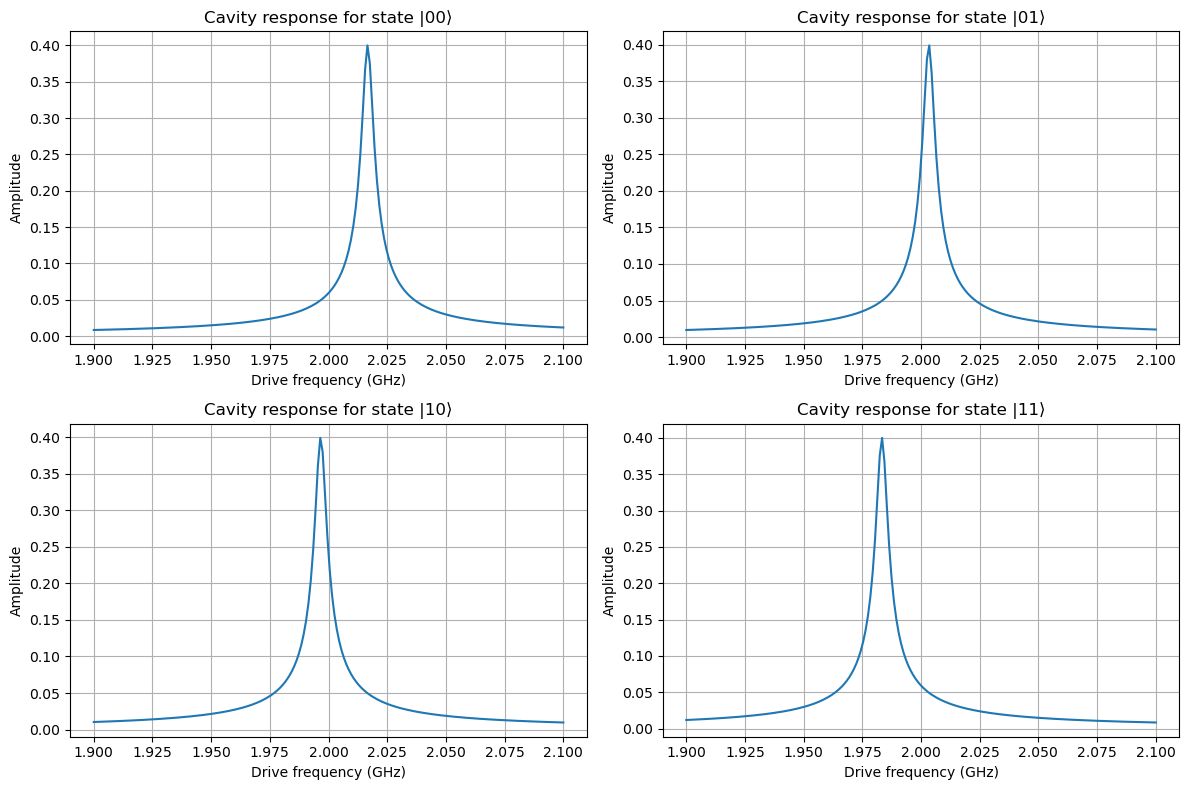

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parameters
ω_r = 2.0 * 2 * np.pi  # Cavity frequency (GHz)
ω_q1 = 3.0 * 2 * np.pi
ω_q2 = 3.5 * 2 * np.pi
g1 = 0.1 * 2 * np.pi
g2 = 0.1 * 2 * np.pi
Δ1 = ω_q1 - ω_r
Δ2 = ω_q2 - ω_r
χ1 = g1**2 / Δ1
χ2 = g2**2 / Δ2

# Hilbert space
N_cav = 15
a = destroy(N_cav)

# Cavity decay
kappa = 0.005 * 2 * np.pi
c_ops = [np.sqrt(kappa) * a]

# Drive amplitudes
ε = 1e-3 * 2 * np.pi  # Weak drive

# Frequency sweep
freqs = np.linspace(ω_r - 0.1 * 2 * np.pi, ω_r + 0.1 * 2 * np.pi, 200)

# States and their σ_z eigenvalues
states = {
    "|00⟩": (+1, +1),
    "|01⟩": (+1, -1),
    "|10⟩": (-1, +1),
    "|11⟩": (-1, -1),
}

# Function to calculate response for given z1, z2
def cavity_response(z1, z2):
    ω_eff = ω_r + χ1 * z1 + χ2 * z2
    response = []
    for ω_d in freqs:
        Δ = ω_eff - ω_d  # Detuning in rotating frame
        H = Δ * a.dag() * a + ε * (a + a.dag())
        rho_ss = steadystate(H, c_ops)
        response.append(np.abs(expect(a, rho_ss)))  # Output amplitude
    return np.array(response)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (label, (z1, z2)) in enumerate(states.items()):
    resp = cavity_response(z1, z2)
    axs[i].plot(freqs / (2 * np.pi), resp)
    axs[i].set_title(f"Cavity response for state {label}")
    axs[i].set_xlabel("Drive frequency (GHz)")
    axs[i].set_ylabel("Amplitude")
    axs[i].grid(True)

plt.tight_layout()
plt.show()
